In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, shapiro, spearmanr



In [2]:
df_raw = pd.read_csv('../data/processed/olist_seller_for_eda.csv')
df = df_raw.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2958 entries, 0 to 2957
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   seller_id                              2958 non-null   object 
 1   seller_city                            2958 non-null   object 
 2   seller_state                           2958 non-null   object 
 3   total_revenue                          2958 non-null   float64
 4   order_count                            2958 non-null   int64  
 5   num_categories                         2958 non-null   int64  
 6   avg_delivery_days                      2958 non-null   int64  
 7   avg_review_score                       2958 non-null   float64
 8   late_shipping_percentage               2958 non-null   float64
 9   cancellation_percentage                2958 non-null   float64
 10  repeat_customer_percentage             2958 non-null   float64
 11  rece

### Descriptive Statistics

- Doanh thu phân bố như thế nào?

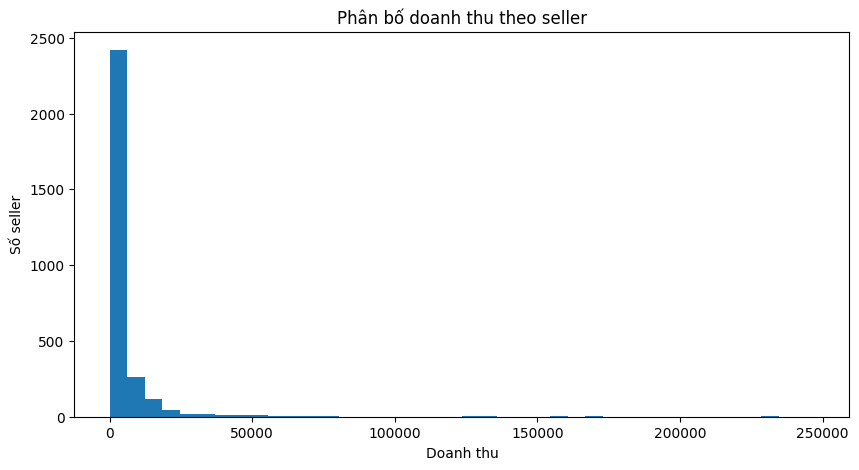

In [4]:
plt.figure(figsize=(10,5))
plt.hist(df["total_revenue"], bins=40)
plt.title("Phân bố doanh thu theo seller")
plt.xlabel("Doanh thu")
plt.ylabel("Số seller")
plt.show()


- Top 1%, 5%, 10%, 20% seller chiếm bao nhiêu % doanh thu

In [ ]:
# sắp xếp seller theo doanh thu giảm dần. 
df_top = df.sort_values("total_revenue", ascending=False).reset_index(drop=True)
frame_top_seller = []

# với mỗi nhóm % seller, tính số seller và % doanh thu nhóm đó chiếm
for pct in [1, 5, 10, 20, 50]:
    # số seller theo tỷ lệ pct trong tổng số seller
    n_seller = max(1, int(len(df_top) * pct / 100))
    
    # tính phân bổ doanh thu của từng nhóm    
    revenue_share = df_top.head(n_seller)["total_revenue"].sum()/ df_top["total_revenue"].sum() * 100
    frame_top_seller.append([pct, n_seller, round(revenue_share, 2)])

concentration_df = pd.DataFrame(
    frame_top_seller,
    columns=["Top Seller %", "Số lượng seller", "% Doanh thu"]
)

concentration_df

,Top Seller %,Số lượng seller,% Doanh thu
0,1,29,25.09
1,5,147,52.04
2,10,295,66.17
3,20,591,81.54
4,50,1479,96.41


In [ ]:
# tính nhóm seller có doanh thu thấp nhất.
frame_bottom_seller = []

for pct in [10, 20]: 
    n_seller = max(1, int(len(df_top) * pct / 100))
    
    # tính phân bổ doanh thu cho nhóm có doanh thu thấp nhất
    revenue_share_bottom = df_top.tail(n_seller)["total_revenue"].sum() / df_top["total_revenue"].sum() * 100
    frame_bottom_seller.append([pct, n_seller, round(revenue_share_bottom, 2)])

bottom_concentration_df = pd.DataFrame(
    frame_bottom_seller,
    columns=["Bottom Seller %", "Số lượng seller", "% Doanh thu nhóm cuối"]
)

print(bottom_concentration_df)


   Bottom Seller %  Số lượng seller  % Doanh thu nhóm cuối
0               10              295                   0.13
1               20              591                   0.44


**Insight**
- Top 10% có tổng là 295 seller, và chiếm tới 66.17% doanh thu. 
- Nhóm 20% seller cuối đóng góp chưa tới 1% doanh thu nhưng lại có đến 594 seller chiếm tới ~20% tổng số nhà bán hàng.

- Top seller khác seller còn lại ở điểm nào 

In [ ]:
# gán nhãn nhóm: seller thuộc top 10% doanh thu là "top seller", và phần còn lại   
df["seller_group"] = np.where(
    df["total_revenue"] >= df["total_revenue"].quantile(0.9),
    "Top Seller",
    "Other Seller"
)

# so sánh các chỉ số giữa 2 nhóm
df.groupby("seller_group")[
    [
        "order_count",
        "avg_review_score",
        "avg_delivery_days",
        "late_shipping_percentage",
        "recency_days",
        "num_categories",
        "cancellation_percentage",
        "repeat_customer_percentage"
    ]
].mean()


,order_count,avg_review_score,avg_delivery_days,late_shipping_percentage,recency_days,num_categories,cancellation_percentage,repeat_customer_percentage
seller_group,,,,,,,,
Other Seller,14.147633,4.128370,11.643877,8.316063,187.903456,6.850113,0.0,0.0
Top Seller,203.195946,4.073345,12.513514,8.200034,91.584459,52.064189,0.0,0.0


In [ ]:
# xem bang nào có nhiều top Seller và doanh thu cao nhất

# tính số lượng seller và tổng doanh thu của top seller ở từng bang
top_state = (
    df[df["seller_group"] == "Top Seller"]
    .groupby("seller_state")
    .agg(
        seller_count=("seller_id", "count"),
        total_revenue=("total_revenue", "sum")
    )
    .sort_values("total_revenue", ascending=False)
).reset_index()

# tính % đóng góp doanh thu của mỗi bang thuộc top seller
total_top_revenue = top_state["total_revenue"].sum()
top_state["revenue_share_pct"] = (
    top_state["total_revenue"] /
    total_top_revenue * 100
).round(2)

top_state.head(10)

,seller_state,seller_count,total_revenue,revenue_share_pct
0,SP,181,6834461.96,66.94
1,PR,31,821150.24,8.04
2,MG,28,711951.88,6.97
3,RJ,15,638855.93,6.26
4,SC,19,456766.29,4.47
5,BA,3,263499.97,2.58
6,RS,11,254010.52,2.49
7,PE,2,88600.58,0.87
8,MA,1,48169.50,0.47
9,DF,2,33460.85,0.33


   seller_state  total_revenue
21           SP     9956683.54
14           PR     1416994.74
7            MG     1184259.36
15           RJ      911918.67
19           SC      717739.37
18           RS      429712.53
1            BA      297146.93
3            DF      112892.78
12           PE      103486.10
5            GO       77089.48


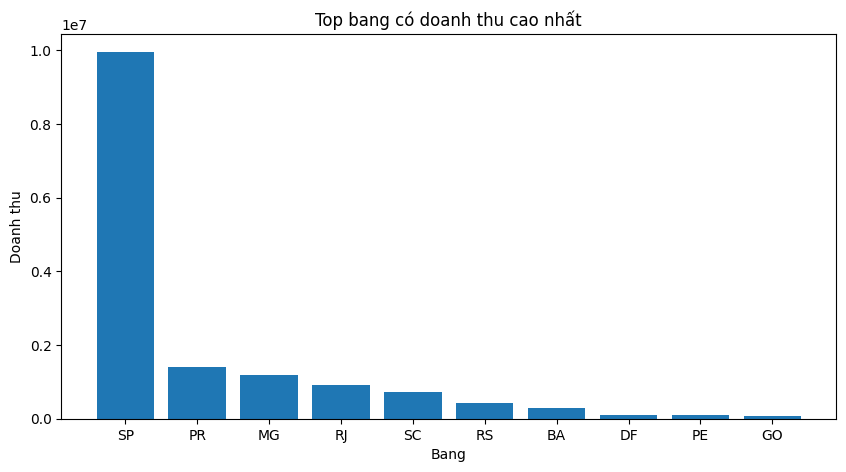

In [ ]:
# tổng doanh thu theo bang
top10_state = (
    df.groupby("seller_state")["total_revenue"]
      .sum()
      .reset_index()
      .sort_values("total_revenue", ascending=False)
      .head(10)
)
print(top10_state)

# Vẽ biểu đồ
plt.figure(figsize=(10,5))
plt.bar(top10_state["seller_state"], top10_state["total_revenue"])
plt.title("Top bang có doanh thu cao nhất")
plt.xlabel("Bang")
plt.ylabel("Doanh thu")
plt.show()


**Insight**
- seller bán nhiều nhóm sản phẩm thường có doanh thu cao hơn, cho thấy mở rộng danh mục có thể là một đòn bẩy tăng doanh thu.


C:\Users\longl\AppData\Local\Temp\ipykernel_18272\396841480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="seller_group", y="avg_review_score", data=df, palette="Set2")


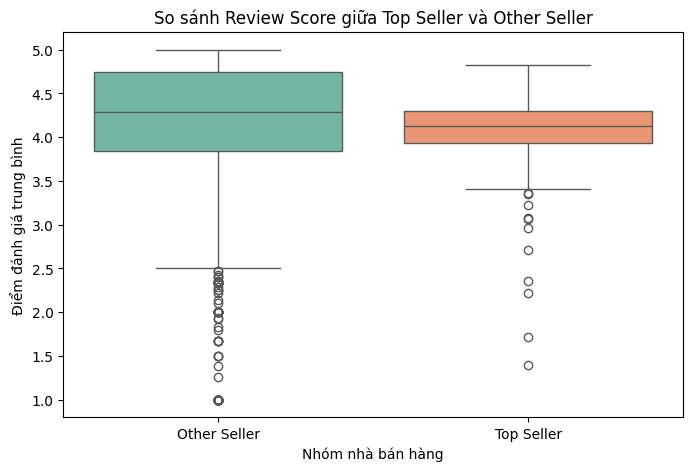

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="seller_group", y="avg_review_score", data=df, palette="Set2")
plt.title("So sánh Review Score giữa Top Seller và Other Seller")
plt.xlabel("Nhóm nhà bán hàng")
plt.ylabel("Điểm đánh giá trung bình")
plt.show()

**Insight**
- Seller có doanh thu không có nghĩa là họ vận hành logictis và được đánh giá tốt hơn. Họ chỉ bán được nhiều hơn chứ không chăm sóc khách hàng tốt hơn
- seller càng lâu không hoạt động thì doanh thu càng thấp, tần suất phát sinh đơn hàng (recency) là yếu tố quyết định dòng tiền của doanh nghiệp. Nhóm seller để thời gian không có đơn kéo dài đang tạo ra một khoảng trống sụt giảm doanh thu      


### KẾT LUẬN CUỐI CÙNG
- Top 10% chỉ có 297 seller nhưng chiếm tới 66.29% doạnh thu
- Bang SP (São Paolo) chiếm tới 66.94% doanh thu nhưng chỉ có 181 seller (6% seller)
- Top seller không hề có điểm đánh giá (~4.1) và giao hàng (~8.2) tốt hơn, tương đương với other seller.
- Số lượng danh mục sản phẩm của top seller nhiểu hơn các seller còn lại.
- Những nhà bán hàng nào hoạt động (có đơn thường xuyên) thì sẽ có doanh thu cao hơn
- Và tỷ lệ quay lại cũng không có khác biệt những top và các seller khác

### Đặt giả thuyết 

Vấn đề 1: Tại sao chỉ một nhóm nhỏ seller lại tạo ra gần hết doanh thu?

Top Seller có thực sự tạo ra nhiều đơn hàng hơn Other Seller hay sự khác biệt chỉ là ngẫu nhiên?
- H0: Top Seller và Other Seller có số lượng đơn hàng trung bình tương đương nhau.
- H1: Top Seller có số lượng đơn hàng trung bình cao hơn Other Seller.

In [ ]:
top = df.loc[df["seller_group"]=="Top Seller","order_count"]
other = df.loc[df["seller_group"]=="Other Seller","order_count"]

# kiểm tra xem dữ liệu có phân phối chuẩn không
print(shapiro(top))
print(shapiro(other))

ShapiroResult(statistic=0.6063835620880127, pvalue=1.8441033748409234e-25)
ShapiroResult(statistic=0.5707521438598633, pvalue=0.0)


- Kết luận sau khi kiểm định shapiro: dữ liệu không tuân theo phân phối chuẩn

In [ ]:
# kiểm định top other có số lượng đơn hàng cao hơn other seller 
# là có ý nghĩa thống kê hay chỉ ngẫu nhiên
stat, p_value = mannwhitneyu(
    top,
    other,
    alternative="greater"
)

print(stat)
print(p_value)

752602.0
2.365319414543977e-147


Why1: Tại sao Top Seller tạo ra doanh thu cao hơn?
    - Vì top seller có nhiều đơn hàng hơn.

In [ ]:
metrics = [
    "order_count",
    "avg_review_score",
    "avg_delivery_days",
    "late_shipping_percentage",
    "recency_days",
    "num_categories",
    "cancellation_percentage",
    "repeat_customer_percentage"
]

# trung bình các chỉ số cho từng nhóm seller
summary = df.groupby("seller_group")[metrics].mean().reset_index()
print(summary)

   seller_group  order_count  avg_review_score  avg_delivery_days  \
0  Other Seller    14.147633          4.128370          11.643877   
1    Top Seller   203.195946          4.073345          12.513514   

   late_shipping_percentage  recency_days  num_categories  \
0                  8.316063    187.903456        6.850113   
1                  8.200034     91.584459       52.064189   

   cancellation_percentage  repeat_customer_percentage  
0                      0.0                         0.0  
1                      0.0                         0.0  


Why2: Tại sao Top Seller có nhiều đơn hàng hơn?
    - Vì Top Seller bán nhiều danh mục sản phẩm hơn.

In [ ]:
# trung bình order_count và num_categories theo nhóm
summary = df.groupby("seller_group")[["order_count", "num_categories"]].mean().reset_index()
print(summary)

   seller_group  order_count  num_categories
0  Other Seller    14.147633        6.850113
1    Top Seller   203.195946       52.064189


Why3: Tại sao Top Seller bán nhiều danh mục sản phẩm hơn?
    - Vì họ có năng lực vận hành tốt hơn (giao hàng nhanh hơn, ít trễ hơn)

In [32]:
# so sánh chỉ số vận hành theo nhóm 
summary_ops = df.groupby("seller_group")[["avg_delivery_days", "late_shipping_percentage"]].mean().reset_index()
print(summary_ops)


   seller_group  avg_delivery_days  late_shipping_percentage
0  Other Seller          11.643877                  8.316063
1    Top Seller          12.513514                  8.200034


**Nguyên nhân gốc rễ cho vấn đề 1**: 
Top Seller sở hữu danh mục sản phẩm đa dạng hơn, cho phép tiếp cận nhiều nhu cầu của khách hàng hơn và tăng khả năng phát sinh giao dịch ở nhiều nhóm sản phẩm. Nhờ đó, Top Seller tạo ra số lượng đơn hàng lớn hơn, từ đó đóng góp phần lớn doanh thu.

Vấn đề 2: Tại sao phần lớn seller còn lại không thể tăng trưởng?

Seller có nhiều category hơn có thực sự tạo nhiều doanh thu hơn không?
- H0: Số lượng danh mục sản phẩm không liên quan tới doanh thu.
- H1: Seller bán nhiều danh mục hơn có xu hướng đạt doanh thu cao hơn.

In [ ]:
# mối liên hệ giữa danh mục sản phẩm mà người bán cung cấp và số tiền họ thu được
# liệu bán nhiều sản phẩm có tạo ra nhiều doanh thu hơn không   
rho,p = spearmanr(
    df["num_categories"],
    df["total_revenue"]
)

print("rho =",rho)
print("p =",p)

rho = 0.8037244505608474
p = 0.0


- Kết luận: dữ liệu cho thấy càng có nhiều loại sản phẩm thì doanh thu càng cao

Why1: Tại sao phần lớn seller có doanh thu thấp?
    - Vì có số lượng đơn hàng ít hơn.

In [17]:
summary = df.groupby("seller_group")[["order_count"]].mean().reset_index()
print(summary)

   seller_group  order_count
0  Other Seller    14.147633
1    Top Seller   203.195946


Why2: Tạo sao các seller còn lại có ít lượng đơn hàng hơn
    - Vì họ bán ít danh mục sản phẩm hơn.

In [18]:
summary = df.groupby("seller_group")[["num_categories"]].mean().reset_index()
print(summary)

   seller_group  num_categories
0  Other Seller        6.850113
1    Top Seller       52.064189


Why3: Tại sao phần lớn seller bán ít danh mục sản phẩm
    - hoạt động không thường xuyên, dẫn đến không có mở rộng danh mục.

In [19]:
summary = df.groupby("seller_group")["recency_days"].mean().reset_index()
print(summary)

   seller_group  recency_days
0  Other Seller    187.903456
1    Top Seller     91.584459


Why4: Tại sao seller nhỏ không hoạt động thường xuyên
    - Other Seller ít hoạt động vì năng lực vận hành hạn chế (giao hàng chậm, tỷ lệ giao trễ cao)

In [20]:
summary_ops = df.groupby("seller_group")[["avg_delivery_days", "late_shipping_percentage"]].mean().reset_index()
print(summary_ops)

   seller_group  avg_delivery_days  late_shipping_percentage
0  Other Seller          11.643877                  8.316063
1    Top Seller          12.513514                  8.200034


**Nguyên nhân gốc rể của vấn đề 2**: 
Phân tích cho thấy doanh thu thấp của Other Seller chủ yếu đến từ số lượng đơn hàng thấp. Nguyên nhân sâu hơn là nhóm seller này hoạt động không thường xuyên, dẫn đến ít mở rộng danh mục sản phẩm và chỉ đáp ứng được phạm vi nhu cầu khách hàng hẹp hơn. Trong khi đó, năng lực vận hành không phải là yếu tố tạo ra sự khác biệt về doanh thu giữa các nhóm seller.

Vấn đề 3: Vì sao doanh thu lại tập trung ở bang SP?

Seller ở SP có doanh thu cao hơn seller các bang khác không?
- H0: Doanh thu trung bình của seller tại SP không khác các bang khác.
- H1: Seller tại SP có doanh thu cao hơn.

In [21]:
sp = df.loc[df["seller_state"]=="SP","total_revenue"]
non_sp = df.loc[df["seller_state"]!="SP","total_revenue"]

print(shapiro(sp.sample(min(500,len(sp)), random_state=42)))
print(shapiro(non_sp.sample(500, random_state=42)))

ShapiroResult(statistic=0.2596897482872009, pvalue=1.8864139796894255e-40)
ShapiroResult(statistic=0.3926844596862793, pvalue=9.639648724122648e-38)


In [ ]:
# doanh thu của seller ở bang SP có vượt trội hơn seller ở các bang khác không
stat, p_value = mannwhitneyu(
    sp,
    non_sp,
    alternative="greater"
)

print(stat)
print(p_value)

1065555.5
0.29247301487946464


In [33]:
# tỷ lệ giao hàng trễ của bang SP và các bang khác
sp_late = df.loc[df["seller_state"] == "SP", "late_shipping_percentage"]
others_late = df.loc[df["seller_state"] != "SP", "late_shipping_percentage"]

stat, p_value = mannwhitneyu(sp_late, others_late, alternative="two-sided")
print("Mann-Whitney U statistic:", stat)
print("p-value:", p_value)

Mann-Whitney U statistic: 1217077.5
p-value: 6.0303933687331824e-15


Why1: Tại sao SP tạo ra nhiều doanh thu hơn
    - Vì có nhiều Top seller hơn

In [ ]:
# số lượng top seller ở từng bang
top_seller_count = (
    df.groupby("seller_state")["seller_group"]
      .apply(lambda x: (x == "Top Seller").sum())
      .reset_index()
)
top_seller_count.columns = ["seller_state", "num_top_seller"]
# tổng doanh thu ở từng bang
sp_revenue = df.groupby("seller_state")["total_revenue"].sum().reset_index()

summary = sp_revenue.merge(top_seller_count, on="seller_state")
print(summary)


   seller_state  total_revenue  num_top_seller
0            AM        1258.80               0
1            BA      297146.93               3
2            CE       23724.05               0
3            DF      112892.78               2
4            ES       58853.49               1
5            GO       77089.48               1
6            MA       48169.50               1
7            MG     1184259.36              28
8            MS        9750.65               0
9            MT       21623.67               0
10           PA        1393.11               0
11           PB       17844.43               1
12           PE      103486.10               2
13           PI        2791.55               0
14           PR     1416994.74              31
15           RJ      911918.67              15
16           RN       11296.71               0
17           RO        5474.98               0
18           RS      429712.53              11
19           SC      717739.37              19
20           

Why2: Vì sao SP có nhiều top seller 
    - Vì seller ở SP bán nhiều danh mục sản phẩm hơn

In [ ]:
# tính số danh mục trung bình theo bang
avg_categories = df.groupby("seller_state")["num_categories"].mean().reset_index()
avg_categories.columns = ["seller_state", "avg_num_categories"]

summary = top_seller_count.merge(avg_categories, on="seller_state")
print(summary)

   seller_state  num_top_seller  avg_num_categories
0            AM               0            3.000000
1            BA               3            6.777778
2            CE               0            2.250000
3            DF               2           12.466667
4            ES               1            4.409091
5            GO               1            6.000000
6            MA               1           44.000000
7            MG              28           11.547009
8            MS               0            6.200000
9            MT               0           15.000000
10           PA               0            7.000000
11           PB               1            4.666667
12           PE               2            7.000000
13           PI               0            4.000000
14           PR              31            9.057402
15           RJ              15            9.098160
16           RN               0            2.600000
17           RO               0            5.500000
18          

Why3: Tại sao seller ở SP bán nhiều danh mục sản phẩm hơn
    - Vì seller ở SP hoạt động thường xuyên 

In [ ]:
# tính trung bình các chỉ số theo bang 
metrics = [
    "num_categories",
    "order_count",
    "recency_days"
]

summary_by_state = df.groupby("seller_state")[metrics].mean().reset_index()
print(summary_by_state)


   seller_state  num_categories  order_count  recency_days
0            AM        3.000000     3.000000    581.000000
1            BA        6.777778    30.555556    148.777778
2            CE        2.250000     7.250000    161.750000
3            DF       12.466667    26.933333    164.866667
4            ES        4.409091    14.090909    146.318182
5            GO        6.000000    11.564103    171.923077
6            MA       44.000000   389.000000     56.000000
7            MG       11.547009    33.098291    187.235043
8            MS        6.200000     9.800000    251.400000
9            MT       15.000000    34.000000     76.000000
10           PA        7.000000     8.000000    256.000000
11           PB        4.666667     5.833333    174.333333
12           PE        7.000000    44.777778    135.333333
13           PI        4.000000    11.000000     55.000000
14           PR        9.057402    22.815710    184.583082
15           RJ        9.098160    25.944785    178.6871

Why4: Tại sao seller ở SP hoạt động thường xuyên hơn?
    - Vì SP có năng lực vận hành tốt, giúp seller dễ dàng xử lý đơn hàng và duy trì hoạt động liên tục.

In [ ]:
metrics = [
    "num_categories",
    "avg_delivery_days",
    "late_shipping_percentage"
]

summary_by_state = df.groupby("seller_state")[metrics].mean().reset_index()
print(summary_by_state)


   seller_state  num_categories  avg_delivery_days  late_shipping_percentage
0            AM        3.000000          48.000000                 66.670000
1            BA        6.777778          15.500000                  4.482222
2            CE        2.250000          19.250000                 13.623333
3            DF       12.466667          12.633333                 10.057667
4            ES        4.409091          12.136364                  5.845455
5            GO        6.000000          14.076923                  9.816154
6            MA       44.000000          17.000000                 23.630000
7            MG       11.547009          12.358974                  6.340812
8            MS        6.200000          10.800000                 13.530000
9            MT       15.000000          13.750000                  3.972500
10           PA        7.000000          13.000000                 12.500000
11           PB        4.666667          12.000000                  2.221667

**Nguyên nhân gốc rễ cho vấn đề 3**:
Phân tích cho thấy doanh thu tập trung tại bang SP chủ yếu do số lượng Top Seller nhiều hơn các bang khác. Các seller tại SP sở hữu danh mục sản phẩm đa dạng hơn và duy trì hoạt động thường xuyên hơn, giúp tạo ra nhiều đơn hàng và đóng góp doanh thu lớn hơn. Bên cạnh đó, kết quả phân tích cho thấy năng lực vận hành tại SP tốt hơn, thể hiện qua thời gian giao hàng ngắn hơn và tỷ lệ giao trễ thấp hơn. Điều này góp phần giúp seller duy trì hoạt động ổn định, mở rộng danh mục sản phẩm và trở thành nhóm đóng góp doanh thu chủ lực của nền tảng.